In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from figutils import cm, set_figure_style, stat_cor

set_figure_style()

ROOT       = ".."
EVAL_DIR   = os.path.join(ROOT, "results", "evaluation", "pangolin", "dev")
TRAIN_DIR  = os.path.join(ROOT, "results", "finetuning",  "pangolin", "dev")
OUTPUT_DIR = os.path.join("pdfs", "pangolin_dev")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUN_NAME = "annotated__frozen__1gpu"
N_EPOCHS = 5
MIN_ALPHA = 5

## 1. Training curves

**Why is val loss consistently lower than train loss?**
The dev run uses `min_alpha_juncs=0`, so the BCE on noisy low-coverage SSU targets inflates train loss.
The val windows also have a sparser splice-site distribution than the train windows, so the randomly-initialised
head's default output is closer to correct on average in val.
There is no dropout, so there is no regularisation gap — the difference is purely data distribution.

In [11]:
log = pd.read_csv(os.path.join(TRAIN_DIR, RUN_NAME, "epoch_log.csv"))
log

,epoch,train_loss,val_loss
0,1,1.783597,0.523834
1,2,0.556049,0.516748
2,3,0.550566,0.510087
3,4,0.548773,0.509806
4,5,0.547423,0.509979


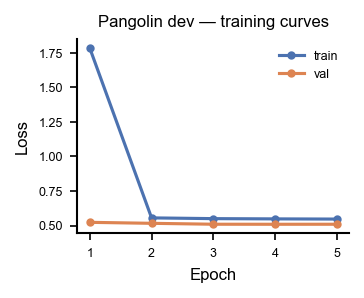

In [12]:
fig, ax = plt.subplots(figsize=(6*cm, 5*cm))
ax.plot(log["epoch"], log["train_loss"], marker="o", ms=3, label="train", color="#4C72B0")
ax.plot(log["epoch"], log["val_loss"],   marker="o", ms=3, label="val",   color="#DD8452")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Pangolin dev — training curves")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "training_curves.pdf"))
plt.show()

## 2. Load SSU predictions (alpha >= 5)

In [13]:
ssu_epochs = []
for epoch in range(1, N_EPOCHS + 1):
    path = os.path.join(EVAL_DIR, RUN_NAME, f"epoch{epoch}", "val", "predictions", "ssu_scores.parquet")
    if os.path.exists(path):
        ssu_epochs.append(pd.read_parquet(path).assign(epoch=epoch))

ssu_all = pd.concat(ssu_epochs, ignore_index=True)
ssu_filt = ssu_all[ssu_all["alpha_juncs"] >= MIN_ALPHA].copy()
print(f"Total rows (all epochs, alpha>={MIN_ALPHA}): {len(ssu_filt):,}")
ssu_filt.head()

Total rows (all epochs, alpha>=5): 60,895


,chrom,exon_pos,strand,role,sample_id,pred_ssu,obs_ssu,alpha_juncs,epoch
0,chr9,133348246,+,unknown,SRR17111303,0.570523,0.998504,8976,1
2,chr9,133348388,+,unknown,SRR17111303,0.343916,0.012622,90,1
3,chr9,133348573,+,unknown,SRR17111303,0.354223,0.000738,7,1
4,chr9,133348922,+,unknown,SRR17111303,0.915563,0.981154,9074,1
5,chr9,133349042,+,unknown,SRR17111303,0.927040,0.990153,21625,1


## 3. SSU Pearson r per epoch — per sample, strands pooled

Note: positive strand r ≈ 0.55, negative strand r ≈ 0 after 5 epochs.
This is expected — the backbone sees the forward-strand sequence and the linear-probe heads
have only 5 epochs to learn the reverse-complement mapping implicitly.

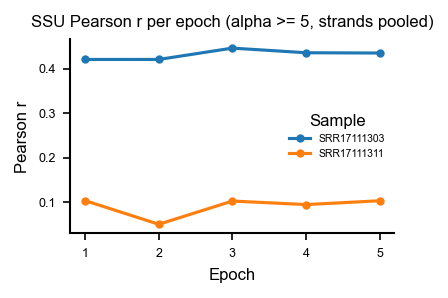

In [14]:
def pearson_r(df):
    r, p = stats.pearsonr(df["obs_ssu"], df["pred_ssu"])
    return pd.Series({"pearson_r": r, "n": len(df)})

r_epoch_sample = (
    ssu_filt
    .groupby(["epoch", "sample_id"])
    .apply(pearson_r, include_groups=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7*cm, 5*cm))
palette = sns.color_palette("tab10", n_colors=r_epoch_sample["sample_id"].nunique())
for i, (sample, grp) in enumerate(r_epoch_sample.groupby("sample_id")):
    ax.plot(grp["epoch"], grp["pearson_r"], marker="o", ms=3, label=sample, color=palette[i])

ax.set_xlabel("Epoch")
ax.set_ylabel("Pearson r")
ax.set_title(f"SSU Pearson r per epoch (alpha >= {MIN_ALPHA}, strands pooled)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(title="Sample", frameon=False, fontsize=5)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "ssu_pearson_r_epochs.pdf"))
plt.show()

## 4. SSU Pearson r by strand — diagnosis

   epoch strand  pearson_r       n
8      5      +   0.706302  4410.0
9      5      -   0.347864  7769.0


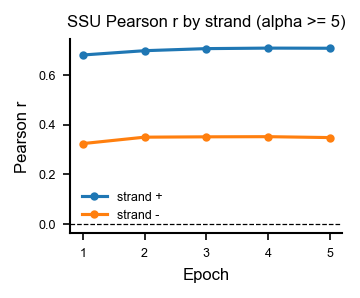

In [15]:
r_epoch_strand = (
    ssu_filt
    .groupby(["epoch", "strand"])
    .apply(pearson_r, include_groups=False)
    .reset_index()
)
print(r_epoch_strand[r_epoch_strand["epoch"] == N_EPOCHS])

fig, ax = plt.subplots(figsize=(6*cm, 5*cm))
for strand, grp in r_epoch_strand.groupby("strand"):
    ax.plot(grp["epoch"], grp["pearson_r"], marker="o", ms=3, label=f"strand {strand}")

ax.axhline(0, color="k", lw=0.6, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Pearson r")
ax.set_title(f"SSU Pearson r by strand (alpha >= {MIN_ALPHA})")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "ssu_pearson_r_by_strand.pdf"))
plt.show()

## 5. SSU scatter — final epoch, per sample, strands pooled

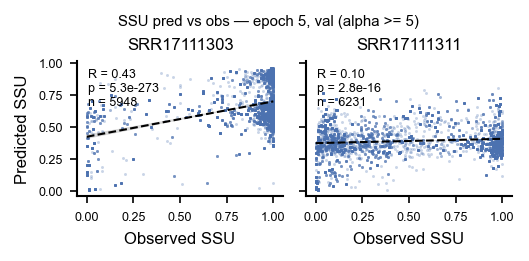

In [16]:
ssu_final = ssu_filt[ssu_filt["epoch"] == N_EPOCHS]

g = sns.FacetGrid(ssu_final, col="sample_id", height=4*cm, aspect=1.1)
g.map_dataframe(
    sns.scatterplot,
    x="obs_ssu", y="pred_ssu",
    s=2, alpha=0.3, linewidth=0, color="#4C72B0", rasterized=True,
)
stat_cor(g, regplot=True, correlation="pearson")
g.set_axis_labels("Observed SSU", "Predicted SSU")
g.set_titles(col_template="{col_name}")
g.figure.suptitle(f"SSU pred vs obs — epoch {N_EPOCHS}, val (alpha >= {MIN_ALPHA})", y=1.04)
g.figure.savefig(os.path.join(OUTPUT_DIR, f"ssu_scatter_epoch{N_EPOCHS}.pdf"), bbox_inches="tight")
plt.show()

## 6. SSU distributions — predicted vs observed

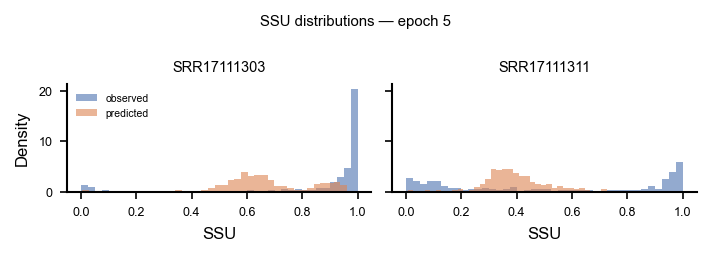

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12*cm, 4*cm), sharey=True)
for ax, (sample, sub) in zip(axes, ssu_final.groupby("sample_id")):
    ax.hist(sub["obs_ssu"],  bins=40, alpha=0.6, density=True, label="observed",  color="#4C72B0")
    ax.hist(sub["pred_ssu"], bins=40, alpha=0.6, density=True, label="predicted", color="#DD8452")
    ax.set_title(sample, fontsize=7)
    ax.set_xlabel("SSU")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, fontsize=5)
fig.suptitle(f"SSU distributions — epoch {N_EPOCHS}", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, f"ssu_dist_epoch{N_EPOCHS}.pdf"), bbox_inches="tight")
plt.show()

## 7. Splice-site classification — predicted probability on positive sites

auPRC cannot be computed: `splice_site_scores.parquet` contains only observed splice sites (all label=1).
Background positions are not sampled by `collect_predictions.py`.
Instead: distribution of pred_splice_prob on true positives — higher is better.

Rows: 19,982  |  all label_rnaseq=1: True


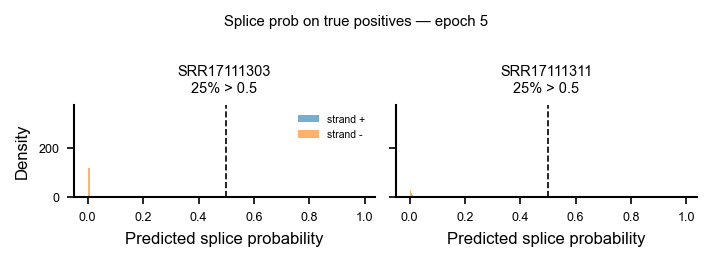

In [18]:
ss = pd.read_parquet(
    os.path.join(EVAL_DIR, RUN_NAME, f"epoch{N_EPOCHS}", "val", "predictions", "splice_site_scores.parquet")
)
print(f"Rows: {len(ss):,}  |  all label_rnaseq=1: {(ss['label_rnaseq']==1).all()}")

fig, axes = plt.subplots(1, 2, figsize=(12*cm, 4*cm), sharey=True)
for ax, (sample, grp) in zip(axes, ss.groupby("sample_id")):
    for strand, sgrp in grp.groupby("strand"):
        ax.hist(sgrp["pred_splice_prob"], bins=40, alpha=0.6, density=True, label=f"strand {strand}")
    ax.axvline(0.5, color="k", lw=0.8, linestyle="--")
    pct_above = (grp["pred_splice_prob"] > 0.5).mean() * 100
    ax.set_title(f"{sample}\n{pct_above:.0f}% > 0.5", fontsize=7)
    ax.set_xlabel("Predicted splice probability")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, fontsize=5)
fig.suptitle(f"Splice prob on true positives — epoch {N_EPOCHS}", y=1.04)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, f"splice_prob_dist_epoch{N_EPOCHS}.pdf"), bbox_inches="tight")
plt.show()